# C07 – XGBoost (M3)
**IT3051 Fundamentals of Data Mining – Mini Project 2026 – PE2 (modelling)**
**Task:** Classification – predict **`Late_delivery_risk`** (1 = late) at order placement.
**Owner:** M3 – Primesh

M3 trains **XGBoost**: trees built one after another, each fixing the mistakes of the earlier ones.

**Install once:** `pip install xgboost`.

### Steps
1. Setup  2. Load data and team decisions  3. Choose the model  4. Default model  5. Tune  6. Compare  7. Save

### Rules
- Only the **training set** is used; the test set is used **once**, in C09.
- Same 5 grouped folds as the whole team. Main score: **ROC-AUC**; business priority: **recall**.
- While testing your code, set `N_ITER = 3`; set it back for the real run.

**Input:** `train_clf_fe.csv`, `clf_m3_selection.json`, `clf_m4_preprocessing.json`
**Output:** rows in `results/clf_experiments.csv`, `results/clf_params_<model>.json`, a chart in `reports/figures/clf_models/`

## Step 1 – Setup

The team's shared helpers for classification:
- `classification_metrics` – the 5 scores. **ROC-AUC** is the main score (how well late orders are separated from on-time ones);
  **recall** is the business priority (how many late orders are caught).
- `make_cv` – the 5 fair folds: orders stay together, same % of late orders in every fold.
- `cv_evaluate` – trains a fresh copy of the model on each fold, scores it, returns the averages and `roc_auc_std` (fold-to-fold noise).
- `log_experiment` – adds a result line to the shared `results/clf_experiments.csv`.
- `build_preprocessor` / `build_full_pipeline` – rebuild C03's encoding, add C04's scaler if needed, then the model – all in one pipeline.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import loguniform

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, TargetEncoder, StandardScaler, RobustScaler, MinMaxScaler
from sklearn.model_selection import StratifiedGroupKFold, RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = ROOT / "data" / "processed"
RESULTS_DIR = ROOT / "results"
FIG_DIR = ROOT / "reports" / "figures" / "clf_models"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
TARGET, GROUP, SEED = "Late_delivery_risk", "Order Id", 42
METRICS = ["roc_auc", "accuracy", "precision", "recall", "f1"]
SCALERS = {"none": None, "standard": StandardScaler, "robust": RobustScaler, "minmax": MinMaxScaler}

def show(fig, name):
    fig.tight_layout(); fig.savefig(FIG_DIR / f"{name}.png", dpi=120); plt.show()

def classification_metrics(y_true, y_pred, y_proba):
    return {"roc_auc": roc_auc_score(y_true, y_proba),
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0)}

def make_cv(X, y, groups, n_splits=5, seed=SEED):
    return list(StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed).split(X, y, groups))

def cv_evaluate(pipe, X, y, cv_splits, return_proba=False):
    rows, oof = [], np.full(len(y), np.nan)
    for i, (tr, va) in enumerate(cv_splits):
        model = clone(pipe).fit(X.iloc[tr], y.iloc[tr])
        proba = model.predict_proba(X.iloc[va])[:, 1]
        oof[va] = proba
        rows.append({"fold": i, **classification_metrics(y.iloc[va], (proba >= 0.5).astype(int), proba)})
    per_fold = pd.DataFrame(rows)
    summary = {m: float(per_fold[m].mean()) for m in METRICS}
    summary["roc_auc_std"] = float(per_fold["roc_auc"].std())
    return (summary, per_fold, oof) if return_proba else (summary, per_fold)

def log_experiment(row, path=RESULTS_DIR / "clf_experiments.csv"):
    new = pd.DataFrame([row])
    out = pd.concat([pd.read_csv(path), new], ignore_index=True) if path.exists() else new
    out.to_csv(path, index=False)

def build_preprocessor(plan):
    parts = []
    if plan["numeric"]:
        parts.append(("num", SimpleImputer(strategy="median"), plan["numeric"]))
    if plan["onehot"]:
        parts.append(("onehot", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                                          ("encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), plan["onehot"]))
    if plan["onehot_rare"]:
        parts.append(("onehot_rare", OneHotEncoder(min_frequency=0.01, handle_unknown="infrequent_if_exist",
                                                   sparse_output=False), plan["onehot_rare"]))
    if plan["target"]:
        parts.append(("target", TargetEncoder(target_type="binary", random_state=SEED), plan["target"]))
    return ColumnTransformer(parts, remainder="drop")

def build_full_pipeline(model, plan, scaler="none"):
    steps = [("prep", build_preprocessor(plan))]
    if SCALERS[scaler] is not None:
        steps.append(("scale", SCALERS[scaler]()))
    steps.append(("model", model))
    return Pipeline(steps)

## Step 2 – Load the data and the team's decisions
Reads C03's features and encoding plan and C04's scaler choice and baseline. The printed baseline ROC-AUC is **the number to beat**.

In [2]:
m3 = json.loads((RESULTS_DIR / "clf_m3_selection.json").read_text(encoding="utf-8"))
FEATURES, PLAN, CATEGORY_COL = m3["features"], m3["plan"], m3["category_column"]
train = pd.read_csv(PROCESSED_DIR / "train_clf_fe.csv")
if CATEGORY_COL == "Category Id":
    train[CATEGORY_COL] = train[CATEGORY_COL].astype(str)
X, y, groups = train.drop(columns=[TARGET]), train[TARGET], train[GROUP]
cv_splits = make_cv(X, y, groups)

m4 = json.loads((RESULTS_DIR / "clf_m4_preprocessing.json").read_text(encoding="utf-8"))
fam = m4["scaler_by_model_family"]
LINEAR_SCALER = fam["linear (Logistic Regression)"]["scaler"]
KNN_SCALER = fam["distance (KNN)"]["scaler"]
MODE_BASELINE_AUC = m4["reference_cv_roc_auc"]["Baseline: Shipping Mode only"]
print(f"Train: {len(X):,} rows, late {y.mean() * 100:.1f}% | features: {FEATURES}")
print(f"Scaler for linear models: {LINEAR_SCALER} | for KNN: {KNN_SCALER}")
print(f"Shipping Mode baseline ROC-AUC to beat: {MODE_BASELINE_AUC}")

Train: 138,231 rows, late 57.2% | features: ['Shipping Mode', 'Market', 'Order Country', 'Category Name', 'Order Item Quantity', 'Customer Segment', 'order_weekday', 'order_month', 'order_hour', 'order_quarter', 'is_weekend']
Scaler for linear models: standard | for KNN: standard
Shipping Mode baseline ROC-AUC to beat: 0.7414


## Step 3 – Choose the model

**How it works (gradient boosting):** a first small tree makes a rough guess; each next tree learns what is still wrong. The sum of all trees
gives a score that is turned into a probability of "late".
**Scaling:** not needed.

| Setting | What it controls |
| --- | --- |
| `n_estimators` | number of trees |
| `learning_rate` | size of each correction (smaller = slower, safer) |
| `max_depth` | depth of each tree |
| `subsample`, `colsample_bytree` | share of rows / features each tree sees |
| `min_child_weight` | blocks tiny, over-specific branches |

In [3]:
from xgboost import XGBClassifier

MODEL_NAME, OWNER = "XGBoost", "M3"
MODEL = XGBClassifier(tree_method="hist", n_estimators=300, learning_rate=0.1, eval_metric="logloss",
                      n_jobs=-1, random_state=SEED)
SCALER = "none"
PARAMS = {"model__n_estimators": [200, 400, 600], "model__learning_rate": [0.03, 0.05, 0.1],
          "model__max_depth": [3, 4, 5, 6, 8], "model__subsample": [0.7, 0.85, 1.0],
          "model__colsample_bytree": [0.7, 0.85, 1.0], "model__min_child_weight": [1, 5, 10]}
N_ITER = 20
SEARCH_JOBS = 1

## Step 4 – Score the model with default settings
Trains with normal settings on each fold and scores it – the **starting point**. Precision/recall/F1 use the usual 0.5 cut-off.

In [4]:
default_pipe = build_full_pipeline(MODEL, PLAN, SCALER)
default_scores, default_folds = cv_evaluate(default_pipe, X, y, cv_splits)
print(f"{MODEL_NAME} (default) - CV ROC-AUC {default_scores['roc_auc']:.4f} ± {default_scores['roc_auc_std']:.4f}")
default_folds.round(4)

XGBoost (default) - CV ROC-AUC 0.7691 ± 0.0043


,fold,roc_auc,accuracy,precision,recall,f1
0,0,0.7646,0.7091,0.8553,0.5963,0.7027
1,1,0.7747,0.7194,0.8522,0.6153,0.7146
2,2,0.7678,0.7068,0.8324,0.6184,0.7096
3,3,0.7724,0.7192,0.8429,0.6132,0.7099
4,4,0.7658,0.7142,0.8446,0.6131,0.7105


## Step 5 – Tune the settings
`RandomizedSearchCV` tries `N_ITER` random combinations on the **same grouped folds** and keeps the best **ROC-AUC**.
- `val_AUC` – score on data the model did not learn from (**the one that matters**).
- `train_AUC` – score on data it learned from.
- `gap` = train − val. A **big gap = overfitting**.

`class_weight="balanced"` (where offered) makes the model pay more attention to the smaller class – it often raises recall.

In [5]:
X_tune, y_tune, tune_splits = X, y, cv_splits
if MODEL_NAME == "KNN":
    keep = pd.Series(groups.unique()).sample(frac=0.3, random_state=SEED)       # KNN is slow: tune on 30% of orders
    mask = groups.isin(keep).to_numpy()
    X_tune, y_tune = X[mask].reset_index(drop=True), y[mask].reset_index(drop=True)
    tune_splits = make_cv(X_tune, y_tune, groups[mask].reset_index(drop=True))

search = RandomizedSearchCV(build_full_pipeline(MODEL, PLAN, SCALER), PARAMS, n_iter=N_ITER, cv=tune_splits,
                            scoring="roc_auc", random_state=SEED, n_jobs=SEARCH_JOBS, return_train_score=True)
search.fit(X_tune, y_tune)
print("Best settings:", search.best_params_)
print(f"Best CV ROC-AUC during tuning: {search.best_score_:.4f}")

results = pd.DataFrame(search.cv_results_)
results["val_AUC"], results["train_AUC"] = results["mean_test_score"], results["mean_train_score"]
results["gap"] = results["train_AUC"] - results["val_AUC"]
results.sort_values("val_AUC", ascending=False)[["params", "val_AUC", "train_AUC", "gap"]].head(10).round(4)

Best settings: {'model__subsample': 1.0, 'model__n_estimators': 200, 'model__min_child_weight': 10, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.7}
Best CV ROC-AUC during tuning: 0.7738


,params,val_AUC,train_AUC,gap
3,"{'model__subsample': 1.0, 'model__n_estimators...",0.7738,0.7891,0.0153
16,"{'model__subsample': 1.0, 'model__n_estimators...",0.7736,0.7929,0.0192
13,"{'model__subsample': 0.85, 'model__n_estimator...",0.7735,0.7973,0.0238
6,"{'model__subsample': 0.7, 'model__n_estimators...",0.7734,0.7937,0.0203
5,"{'model__subsample': 0.85, 'model__n_estimator...",0.7730,0.7977,0.0247
14,"{'model__subsample': 0.7, 'model__n_estimators...",0.7728,0.7948,0.0220
7,"{'model__subsample': 1.0, 'model__n_estimators...",0.7721,0.8023,0.0303
2,"{'model__subsample': 0.85, 'model__n_estimator...",0.7720,0.8027,0.0307
17,"{'model__subsample': 0.7, 'model__n_estimators...",0.7717,0.8036,0.0319
0,"{'model__subsample': 0.85, 'model__n_estimator...",0.7703,0.8131,0.0428


## Step 6 – Score the tuned model and compare
### 6.1 All scores: baseline vs default vs tuned

In [6]:
tuned_pipe = build_full_pipeline(MODEL, PLAN, SCALER).set_params(**search.best_params_)
tuned_scores, tuned_folds = cv_evaluate(tuned_pipe, X, y, cv_splits)
compare = pd.DataFrame({"Shipping Mode baseline": {"roc_auc": MODE_BASELINE_AUC},
                        f"{MODEL_NAME} default": default_scores,
                        f"{MODEL_NAME} tuned": tuned_scores}).T[METRICS + ["roc_auc_std"]]
compare.round(4)

,roc_auc,accuracy,precision,recall,f1,roc_auc_std
Shipping Mode baseline,0.7414,NaN,NaN,NaN,NaN,NaN
XGBoost default,0.7691,0.7138,0.8455,0.6113,0.7095,0.0043
XGBoost tuned,0.7738,0.7224,0.8907,0.5865,0.7073,0.0026


### 6.2 Chart and the two viva answers
**Did tuning help?** Real only if ROC-AUC improved by more than `roc_auc_std`. **Does the model beat the baseline?**

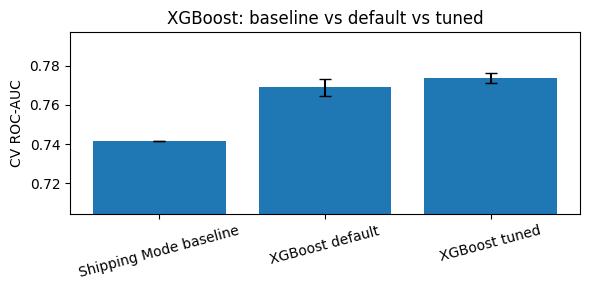

Tuning changed ROC-AUC by +0.0048 (fold noise ± 0.0026)
Improvement is real (bigger than the noise): True
Beats the Shipping Mode baseline: True


In [7]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(compare.index, compare["roc_auc"], yerr=compare["roc_auc_std"].fillna(0), capsize=4)
ax.set_ylabel("CV ROC-AUC"); ax.set_title(f"{MODEL_NAME}: baseline vs default vs tuned")
ax.set_ylim(compare["roc_auc"].min() * 0.95, min(1, compare["roc_auc"].max() * 1.03))
plt.xticks(rotation=15)
show(fig, f"{MODEL_NAME}_comparison")
change = tuned_scores["roc_auc"] - default_scores["roc_auc"]
print(f"Tuning changed ROC-AUC by {change:+.4f} (fold noise ± {tuned_scores['roc_auc_std']:.4f})")
print("Improvement is real (bigger than the noise):", change > tuned_scores["roc_auc_std"])
print("Beats the Shipping Mode baseline:", tuned_scores["roc_auc"] > MODE_BASELINE_AUC)

## Step 7 – Save the results
Adds the default and tuned results to `clf_experiments.csv` and saves `clf_params_<model>.json` – C09 reads these files.

In [8]:
for label, s in [("default", default_scores), ("tuned", tuned_scores)]:
    log_experiment({"owner": OWNER, "experiment": f"{MODEL_NAME}_{label}", "model": MODEL_NAME, "n_features": len(FEATURES),
                    **{m: s[m] for m in METRICS}, "roc_auc_std": s["roc_auc_std"]})
best_params = {k.replace("model__", ""): (v.item() if hasattr(v, "item") else v) for k, v in search.best_params_.items()}
summary = {"model": MODEL_NAME, "owner": OWNER, "scaler": SCALER, "best_params": best_params,
           "cv_roc_auc_default": round(default_scores["roc_auc"], 4), "cv_roc_auc_tuned": round(tuned_scores["roc_auc"], 4),
           "cv_roc_auc_std": round(tuned_scores["roc_auc_std"], 4),
           "cv_scores_tuned": {m: round(tuned_scores[m], 4) for m in METRICS}}
(RESULTS_DIR / f"clf_params_{MODEL_NAME}.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
print(json.dumps(summary, indent=2))

{
  "model": "XGBoost",
  "owner": "M3",
  "scaler": "none",
  "best_params": {
    "subsample": 1.0,
    "n_estimators": 200,
    "min_child_weight": 10,
    "max_depth": 3,
    "learning_rate": 0.05,
    "colsample_bytree": 0.7
  },
  "cv_roc_auc_default": 0.7691,
  "cv_roc_auc_tuned": 0.7738,
  "cv_roc_auc_std": 0.0026,
  "cv_scores_tuned": {
    "roc_auc": 0.7738,
    "accuracy": 0.7224,
    "precision": 0.8907,
    "recall": 0.5865,
    "f1": 0.7073
  }
}


### Summary

In [9]:
print(f"""
MODEL            {MODEL_NAME} ({OWNER}) | scaler {SCALER}
DEFAULT ROC-AUC  {default_scores['roc_auc']:.4f} ± {default_scores['roc_auc_std']:.4f}
TUNED ROC-AUC    {tuned_scores['roc_auc']:.4f} ± {tuned_scores['roc_auc_std']:.4f}
BASELINE         {MODE_BASELINE_AUC} (Shipping Mode) -> beaten: {tuned_scores['roc_auc'] > MODE_BASELINE_AUC}
TUNED AT 0.5     accuracy {tuned_scores['accuracy']:.3f} | precision {tuned_scores['precision']:.3f} | recall {tuned_scores['recall']:.3f} | F1 {tuned_scores['f1']:.3f}
BEST SETTINGS    {best_params}
""")


MODEL            XGBoost (M3) | scaler none
DEFAULT ROC-AUC  0.7691 ± 0.0043
TUNED ROC-AUC    0.7738 ± 0.0026
BASELINE         0.7414 (Shipping Mode) -> beaten: True
TUNED AT 0.5     accuracy 0.722 | precision 0.891 | recall 0.587 | F1 0.707
BEST SETTINGS    {'subsample': 1.0, 'n_estimators': 200, 'min_child_weight': 10, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.7}



**My contribution in one sentence:** I trained and tuned XGBoost for late-delivery risk and compared it with its default settings and the Shipping Mode baseline.